In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import requests

/tmp/ipykernel_561/3427556543.py:4: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  sp500 = pd.read_html(response.text)[0]
/tmp/ipykernel_561/3427556543.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start="2026-01-01")["Close"]
[*********************100%***********************]  200 of 200 completed



 Information Technology
['INTC', 'STX', 'SNDK', 'AMD', 'ON']
Final Portfolio Value: 2.520803776305699


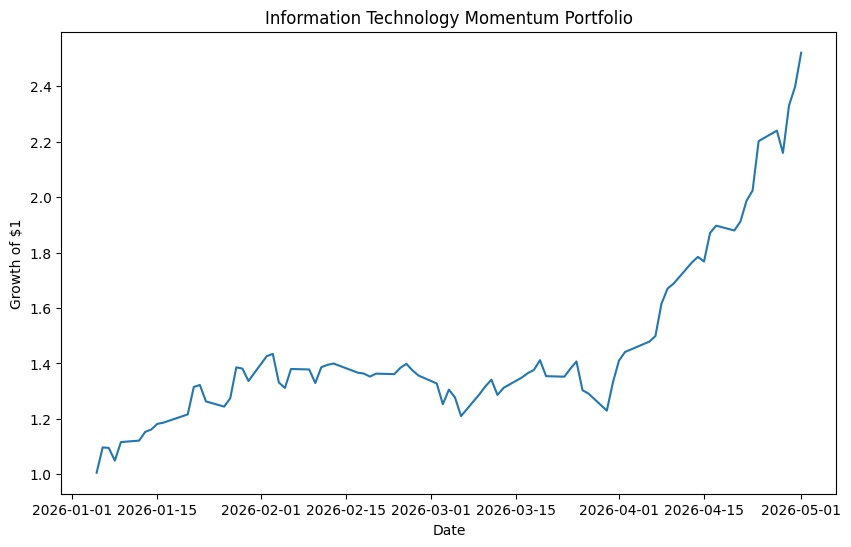


 Industrials
['GNRC', 'PWR', 'FIX', 'URI', 'VRT']
Final Portfolio Value: 1.6869643053268248


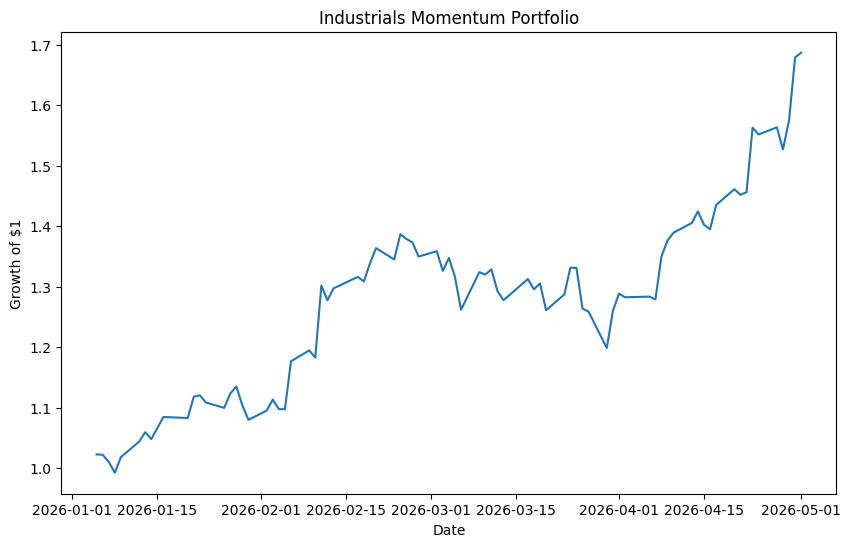


 Consumer Discretionary
['AMZN', 'CVNA', 'SBUX', 'ABNB', 'DASH']
Final Portfolio Value: 1.0582829683628487


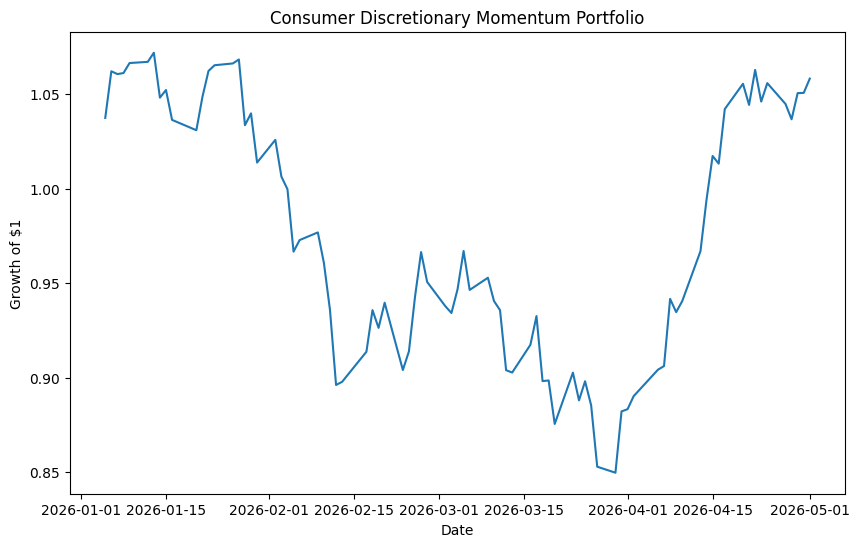

In [ ]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)
sp500 = pd.read_html(response.text)[0]
sp500["Symbol"] = sp500["Symbol"].str.replace(".", "-", regex=False)
sectors = ["Information Technology", "Industrials", "Consumer Discretionary"]
sp500 = sp500[sp500["GICS Sector"].isin(sectors)]
tickers = sp500["Symbol"].tolist()
prices = yf.download(tickers, start="2026-01-01")["Close"]
momentum = prices.pct_change(20).iloc[-1].dropna()
top_n = 5

for sector in sectors:
    sector_tickers = sp500[sp500["GICS Sector"] == sector]["Symbol"]
    sector_momentum = momentum[sector_tickers].dropna()
    top_stocks = sector_momentum.sort_values(ascending=False).head(top_n).index.tolist()

    print("\n", sector)
    print(top_stocks)
    sector_prices = prices[top_stocks]
    returns = sector_prices.pct_change().dropna()
    portfolio_returns = returns.mean(axis=1)
    portfolio_growth = (1 + portfolio_returns).cumprod()
    print("Final Portfolio Value:", portfolio_growth.iloc[-1])

    plt.figure(figsize=(10,6))
    plt.plot(portfolio_growth)
    plt.title(f"{sector} Momentum Portfolio")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.show()

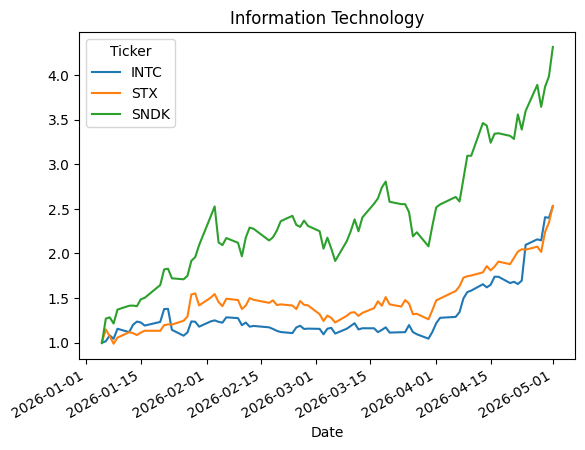

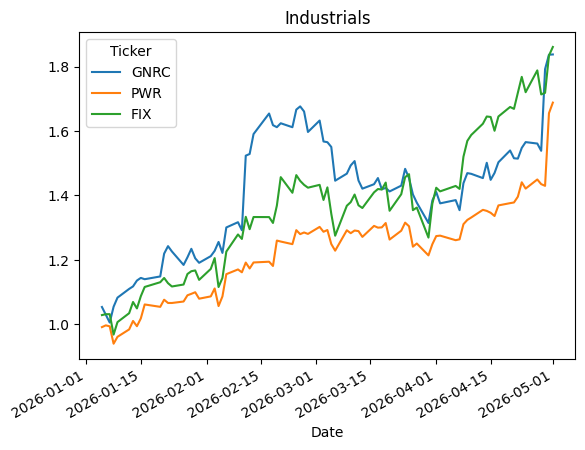

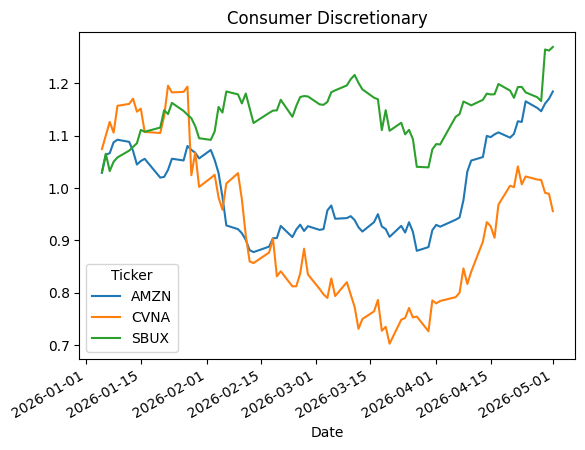

In [ ]:
for sector in sectors:
    stocks = sp500[sp500["GICS Sector"] == sector]["Symbol"]
    sector_momentum = momentum[stocks]
    top_stocks = sector_momentum.sort_values(ascending=False).head(3).index
    data = prices[top_stocks]
    returns = data.pct_change().dropna()
    (1 + returns).cumprod().plot(title=sector)
    plt.show()


 Information Technology
Top Stocks: ['INTC', 'STX', 'SNDK']
Final Portfolio Value: 2.9247035053857484


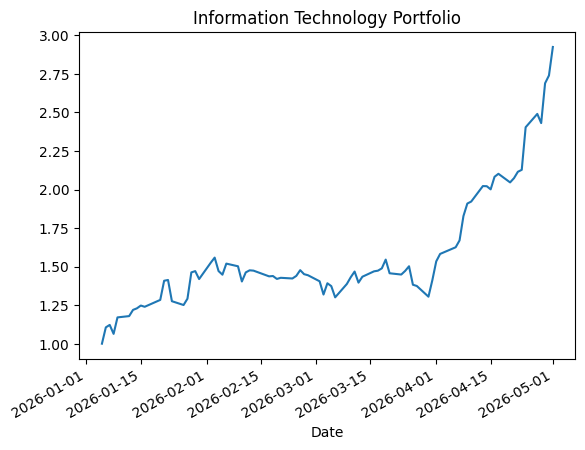


 Industrials
Top Stocks: ['GNRC', 'PWR', 'FIX']
Final Portfolio Value: 1.8249206463335328


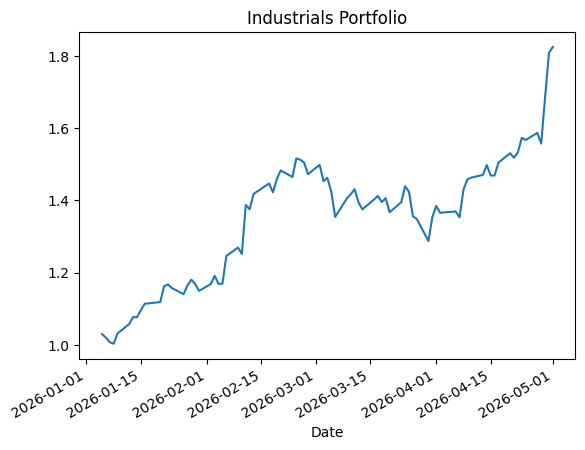


 Consumer Discretionary
Top Stocks: ['AMZN', 'CVNA', 'SBUX']
Final Portfolio Value: 1.1434386600538524


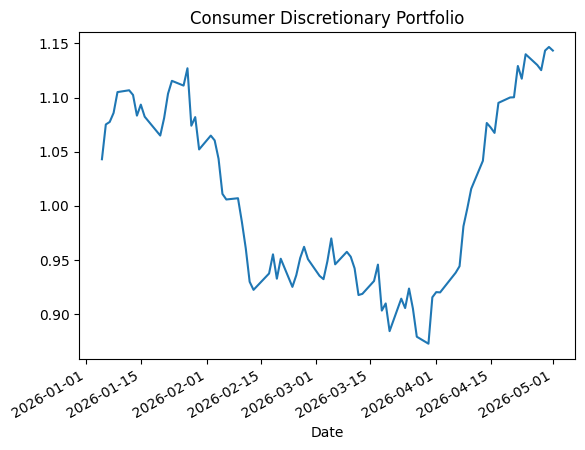

In [ ]:
for sector in sectors:
    stocks = sp500[sp500["GICS Sector"] == sector]["Symbol"]
    sector_momentum = momentum[stocks]
    top_stocks = sector_momentum.sort_values(ascending=False).head(3).index
    data = prices[top_stocks]
    returns = data.pct_change().dropna()
    weights = [0.5, 0.3, 0.2]
    portfolio_returns = returns.dot(weights)
    portfolio_growth = (1 + portfolio_returns).cumprod()
    print("\n", sector)
    print("Top Stocks:", top_stocks.tolist())
    print("Final Portfolio Value:", portfolio_growth.iloc[-1])
    portfolio_growth.plot(title=sector + " Portfolio")
    plt.show()

In [ ]:
yield_percent = 3.6
rf = yield_percent / 100
rf

0.036000000000000004

Change cell below to "Information Technology" / "Industrials" / "Consumer Discretionary" THEN run the cells below

In [ ]:
sector = "Industrials"

In [ ]:
stocks = sp500[sp500["GICS Sector"] == sector]["Symbol"]
sector_momentum = momentum[stocks].dropna()
top_stocks = sector_momentum.sort_values(ascending=False).head(3).index
top_stocks

Index(['GNRC', 'PWR', 'FIX'], dtype='object', name='Ticker')

In [ ]:
data = prices[top_stocks]
returns = data.pct_change().dropna()
returns.tail()

Ticker,GNRC,PWR,FIX
Date,,,
2026-04-27,-0.002852,0.019909,0.039348
2026-04-28,-0.014435,-0.009949,-0.041710
2026-04-29,0.164886,-0.003709,0.002868
2026-04-30,0.024949,0.157763,0.067344
2026-05-01,0.000424,0.019841,0.014547


In [ ]:
returns.corr()

Ticker,GNRC,PWR,FIX
Ticker,,,
GNRC,1.000000,0.250893,0.427620
PWR,0.250893,1.000000,0.784939
FIX,0.427620,0.784939,1.000000


In [ ]:
volatility = returns.std() * (252 ** 0.5)
volatility.name = "Volatility"
volatility

,Volatility
Ticker,
GNRC,0.590303
PWR,0.441631
FIX,0.546502


In [ ]:
growth = (1 + returns).cumprod()
drawdown = growth / growth.cummax() - 1
max_drawdown = drawdown.min()
max_drawdown.name = "Max Drawdown"
max_drawdown

,Max Drawdown
Ticker,
GNRC,-0.215910
PWR,-0.077208
FIX,-0.134268


In [ ]:
sharpe = ((returns.mean() * 252) - rf) / volatility
sharpe.name = "Sharpe"
sharpe

,Sharpe
Ticker,
GNRC,3.396479
PWR,3.785147
FIX,3.711187
